# 🌡️ Indonesia Temperature Forecast — BMKG + LightGBM

Hourly temperature forecasting for Indonesian cities, combining live **BMKG** forecasts with **Open-Meteo** (ERA5) historical data and a **LightGBM** regression model.

**Pipeline:** fetch data → feature engineering → train LightGBM → predict & evaluate → visualize

> Run the cells top to bottom.

## 📦 0. Install Dependencies

In [1]:
# # Install all required libraries
# import subprocess, sys

# packages = [
#     "lightgbm", "pandas", "numpy", "matplotlib",
#     "scikit-learn", "requests", "pyarrow", "joblib"
# ]
# for pkg in packages:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# print("All libraries installed.")

## ⚙️ 1. Imports & Configuration

In [2]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Image, HTML

warnings.filterwarnings("ignore")

# Add the code directory to the Python path
# (adjust if the notebook isn't in the same folder as the .py files)
CODE_DIR = "code"   # change if needed, e.g. "/path/to/bmkg_forecast"
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

# ─── MAIN CONFIGURATION ────────────────────────────────────────────────────
CONFIG = {
    "END_TRAIN":         "2025-12-31",
    "TARGET_DATE":       "2026-04-30",
    "STATIONS":          ["Jakarta"], # "Surabaya", "Bandung"

    "HISTORICAL_START":  "2019-01-01",
    "FORCE_REFRESH":     False,
    "SAVE_MODEL":        True,
    "SHOW_PLOTS":        False,
    "OUTPUT_DIR":        "output",
}
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

print("Configuration:")
for k, v in CONFIG.items():
    print(f"   {k:25s}: {v}")

Configuration:
   END_TRAIN                : 2025-12-31
   TARGET_DATE              : 2026-04-30
   STATIONS                 : ['Jakarta']
   HISTORICAL_START         : 2019-01-01
   FORCE_REFRESH            : False
   SAVE_MODEL               : True
   SHOW_PLOTS               : False
   OUTPUT_DIR               : output


## 📥 2. Fetch Data — BMKG & Open-Meteo

Historical hourly temperature comes from **Open-Meteo** (ERA5 reanalysis, since 2019); short-term forecasts come from **BMKG**. Results are cached to `.parquet` files under `data/` so the notebook doesn't need to re-fetch on every run.

In [3]:
from data_fetcher import fetch_all_stations, STATIONS

print("Fetching data...")
print(f"   Stations : {CONFIG['STATIONS']}")
print(f"   Period   : {CONFIG['HISTORICAL_START']} → today")
print(f"   Refresh  : {CONFIG['FORCE_REFRESH']}\n")

raw_data = fetch_all_stations(
    stations         = {k: v for k, v in STATIONS.items() if k in CONFIG["STATIONS"]},
    historical_start = CONFIG["HISTORICAL_START"],
    force_refresh    = CONFIG["FORCE_REFRESH"],
)

# ─── Data preview ──────────────────────────────────────────────────────────
print("\nData summary:")
print("-" * 70)
for name, df in raw_data.items():
    if df.empty:
        print(f"  !  {name}: EMPTY")
    else:
        src_counts = df["source"].value_counts().to_dict() if "source" in df.columns else {}
        print(f"  ok {name}: {len(df):,} rows | "
              f"{df['timestamp'].min().date()} → {df['timestamp'].max().date()} | "
              f"Source: {src_counts}")
print("-" * 70)

2026-07-25 04:04:07,503 - INFO - [Cache] Loading Jakarta dari data\jakarta_raw.parquet


Fetching data...
   Stations : ['Jakarta']
   Period   : 2019-01-01 → today
   Refresh  : False


Data summary:
----------------------------------------------------------------------
  ok Jakarta: 64,147 rows | 2019-01-01 → 2026-05-04 | Source: {'openmeteo_historical': 64128, 'bmkg_forecast': 19}
----------------------------------------------------------------------


### Raw Data Preview (First Station)

Station: Jakarta
Shape  : (64147, 8)
Columns: ['timestamp', 'temperature', 'humidity', 'wind_speed', 'precipitation', 'station', 'source', 'weather_code']



,timestamp,temperature,humidity,wind_speed,source
64137,2026-05-03 20:00:00,26.0,91.0,3.5,bmkg_forecast
64138,2026-05-03 23:00:00,25.0,93.0,1.8,bmkg_forecast
64139,2026-05-04 02:00:00,25.0,95.0,1.9,bmkg_forecast
64140,2026-05-04 05:00:00,24.0,96.0,3.4,bmkg_forecast
64141,2026-05-04 08:00:00,28.0,82.0,3.4,bmkg_forecast
64142,2026-05-04 11:00:00,29.0,76.0,5.4,bmkg_forecast
64143,2026-05-04 14:00:00,28.0,80.0,5.4,bmkg_forecast
64144,2026-05-04 17:00:00,26.0,91.0,4.8,bmkg_forecast
64145,2026-05-04 20:00:00,25.0,92.0,4.8,bmkg_forecast
64146,2026-05-04 23:00:00,25.0,94.0,4.3,bmkg_forecast


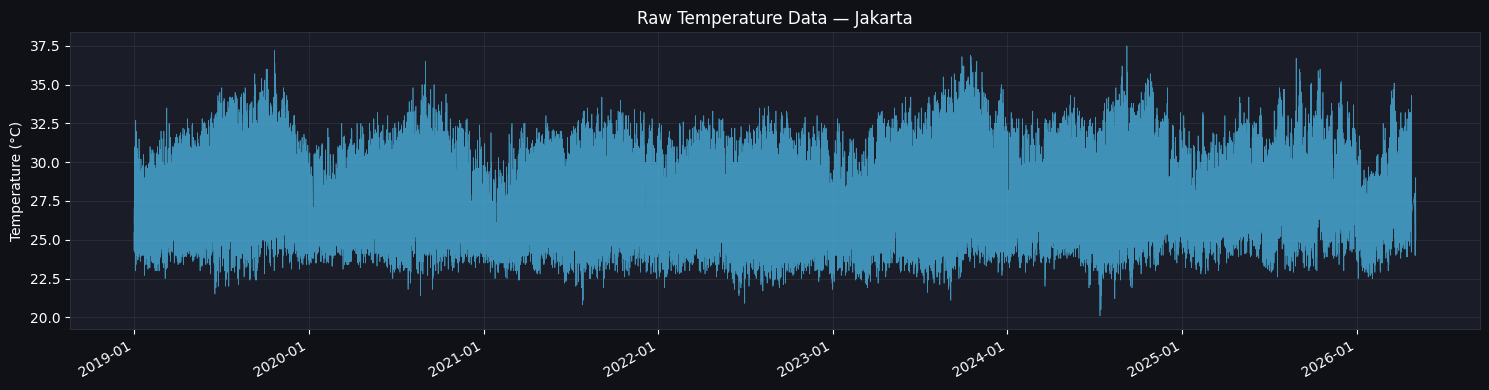

Plot saved.


In [4]:
first_station = CONFIG["STATIONS"][0]
df_raw_sample = raw_data[first_station]

print(f"Station: {first_station}")
print(f"Shape  : {df_raw_sample.shape}")
print(f"Columns: {list(df_raw_sample.columns)}")
print()
display(df_raw_sample[["timestamp", "temperature", "humidity", "wind_speed", "source"]].tail(10))

# Plot raw data
fig, ax = plt.subplots(figsize=(15, 4), facecolor="#0f1117")
ax.set_facecolor("#1a1d27")
ax.plot(df_raw_sample["timestamp"], df_raw_sample["temperature"],
        color="#4fc3f7", lw=0.5, alpha=0.7)
ax.set_title(f"Raw Temperature Data — {first_station}", color="white")
ax.set_ylabel("Temperature (°C)", color="white")
ax.tick_params(colors="white")
ax.spines[:].set_color("#2a2d3a")
ax.grid(True, alpha=0.15, color="gray")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/{first_station.lower()}_raw_data.png", dpi=120, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Plot saved.")






## 🔧 3. Feature Engineering

| Category | Features |
|---|---|
| **Cyclical time** | sin/cos of hour, day-of-week, day-of-month, month, day-of-year |
| **Calendar** | hour, dayofweek, month, year, quarter, is_weekend, is_rainy_season |
| **Lag** | temperature at t-1, t-2, t-3, t-6, t-12, t-24, t-48, t-72h |
| **Rolling stats** | mean/std/min/max over 7d, 14d, 30d, 60d, 90d |
| **Momentum** | temperature delta over 1, 3, 6, 12, 24h |
| **Weather aux** | humidity, wind speed (+ lag-1, lag-24) |

In [5]:
from preprocessing import run_preprocessing, get_feature_columns, TARGET_COL

processed_data = {}

for name, df_raw in raw_data.items():
    if df_raw.empty:
        print(f"  !  {name}: skipped (empty data)")
        continue
    print(f"  >  Preprocessing {name} ...", end=" ")
    df_proc = run_preprocessing(df_raw, station_name=name, drop_na=True)
    processed_data[name] = df_proc
    feat_cols = get_feature_columns(df_proc)
    print(f"ok  {len(df_proc):,} rows | {len(feat_cols)} features")

print("\nPreprocessing complete for all stations.")

2026-07-25 04:04:08,755 - INFO - [Preprocessing] Starting for station: Jakarta | initial rows: 64147
2026-07-25 04:04:08,883 - INFO - Resampled to hourly: 64344 rows.


  >  Preprocessing Jakarta ... 

2026-07-25 04:04:09,113 - INFO - [Preprocessing] Done: 64195/64344 valid rows.


ok  64,195 rows | 60 features

Preprocessing complete for all stations.


### Generated Feature Inspection

In [6]:
first_station = CONFIG["STATIONS"][0]
df_proc_sample = processed_data[first_station]
feat_cols = get_feature_columns(df_proc_sample)

print(f"Total features: {len(feat_cols)}")
print("\nAll features:")
for i, c in enumerate(feat_cols, 1):
    print(f"  {i:3d}. {c}")

print("\nSample data after preprocessing:")
display(df_proc_sample[["timestamp", "temperature",
                          "sin_hour", "cos_hour",
                          "sin_month", "cos_month",
                          "lag_24h", "roll_mean_7d",
                          "momentum_1h"]].tail(5))

Total features: 60

All features:
    1. humidity
    2. wind_speed
    3. precipitation
    4. sin_hour
    5. cos_hour
    6. sin_dayofweek
    7. cos_dayofweek
    8. sin_dayofmonth
    9. cos_dayofmonth
   10. sin_month
   11. cos_month
   12. sin_dayofyear
   13. cos_dayofyear
   14. hour
   15. dayofweek
   16. month
   17. year
   18. quarter
   19. is_weekend
   20. is_rainy_season
   21. lag_1h
   22. lag_2h
   23. lag_3h
   24. lag_6h
   25. lag_12h
   26. lag_24h
   27. lag_48h
   28. lag_72h
   29. roll_mean_7d
   30. roll_std_7d
   31. roll_min_7d
   32. roll_max_7d
   33. roll_mean_14d
   34. roll_std_14d
   35. roll_min_14d
   36. roll_max_14d
   37. roll_mean_30d
   38. roll_std_30d
   39. roll_min_30d
   40. roll_max_30d
   41. roll_mean_60d
   42. roll_std_60d
   43. roll_min_60d
   44. roll_max_60d
   45. roll_mean_90d
   46. roll_std_90d
   47. roll_min_90d
   48. roll_max_90d
   49. momentum_1h
   50. momentum_3h
   51. momentum_6h
   52. momentum_12h
   53. moment

,timestamp,temperature,sin_hour,cos_hour,sin_month,cos_month,lag_24h,roll_mean_7d,momentum_1h
64190,2026-05-04 19:00:00,25.333333,-0.965926,0.258819,0.5,-0.866025,26.000000,NaN,-0.333333
64191,2026-05-04 20:00:00,25.000000,-0.866025,0.500000,0.5,-0.866025,26.000000,NaN,-0.333333
64192,2026-05-04 21:00:00,25.000000,-0.707107,0.707107,0.5,-0.866025,25.666667,NaN,0.000000
64193,2026-05-04 22:00:00,25.000000,-0.500000,0.866025,0.5,-0.866025,25.333333,NaN,0.000000
64194,2026-05-04 23:00:00,25.000000,-0.258819,0.965926,0.5,-0.866025,25.000000,NaN,0.000000


## 🤖 4. Train LightGBM Model

One model per station: trained up to `END_TRAIN`, validated on the last 10% of the training set, with early stopping after 80 rounds and evaluation through `TARGET_DATE`.

In [7]:
from model import TemperatureForecastModel
import os

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
models = {}

for name, df_proc in processed_data.items():
    print(f"\n{'='*55}")
    print(f" Training: {name}")
    print(f"{'='*55}")

    mdl = TemperatureForecastModel(
        end_train   = CONFIG["END_TRAIN"],
        target_date = CONFIG["TARGET_DATE"],
        station     = name,
    )
    mdl.fit(df_proc)
    models[name] = mdl
    print(f"  ok  Model {name} trained.")

print("\nAll models trained.")

2026-07-25 04:04:11,116 - INFO - Train: 61345 rows (2019-01-01 00:00:00 → 2025-12-31 00:00:00)
Test : 2795 rows (2025-12-31 01:00:00 → 2026-04-26 11:00:00)
2026-07-25 04:04:11,118 - INFO - [Model] Feature columns: 60 features
2026-07-25 04:04:11,144 - INFO - [Model] Training: 55211 | Validation: 6134



 Training: Jakarta
[200]	train's l1: 0.0253904	train's rmse: 0.0355655	valid's l1: 0.0469146	valid's rmse: 0.0953223
[400]	train's l1: 0.0192971	train's rmse: 0.0262194	valid's l1: 0.042996	valid's rmse: 0.089045
[600]	train's l1: 0.0158069	train's rmse: 0.021185	valid's l1: 0.0417371	valid's rmse: 0.0871987
[800]	train's l1: 0.0132728	train's rmse: 0.0176189	valid's l1: 0.0409973	valid's rmse: 0.0864379
[1000]	train's l1: 0.0113289	train's rmse: 0.014934	valid's l1: 0.0404108	valid's rmse: 0.0858166
[1200]	train's l1: 0.00984956	train's rmse: 0.0129164	valid's l1: 0.0400554	valid's rmse: 0.0854463
[1400]	train's l1: 0.00866918	train's rmse: 0.0113166	valid's l1: 0.0398638	valid's rmse: 0.0852693


2026-07-25 04:04:46,989 - INFO - [Metrics-Train] MAE=0.011°C | RMSE=0.029°C | MAPE=0.04% | R²=0.9999


  ok  Model Jakarta trained.

All models trained.


## 📊 5. Predict & Evaluate

Runs predictions on the test window (from `END_TRAIN` to `TARGET_DATE`).

In [8]:
results = {}

for name, mdl in models.items():
    df_proc = processed_data[name]

    print(f"\n── Predicting: {name} ─────────────────────────────")

    # Predict on the test window
    df_test_result = mdl.predict()

    # Predict on the full period (for plotting)
    df_full_result = mdl.predict_full(df_proc)

    # Metrics
    metrics = mdl.get_metrics()

    # Save predictions to CSV
    csv_path = os.path.join(CONFIG["OUTPUT_DIR"], f"{name.lower()}_predictions.csv")
    df_test_result.to_csv(csv_path, index=False)

    results[name] = {
        "model":       mdl,
        "metrics":     metrics,
        "test_pred":   df_test_result,
        "full_pred":   df_full_result,
        "csv_path":    csv_path,
    }
    print(f"  MAE  = {metrics.get('mae',  0):.3f}°C")
    print(f"  RMSE = {metrics.get('rmse', 0):.3f}°C")
    print(f"  MAPE = {metrics.get('mape', 0):.2f}%")
    print(f"  R²   = {metrics.get('r2',   0):.4f}")
    print(f"  CSV  : {csv_path}")

print("\nPrediction complete.")


── Predicting: Jakarta ─────────────────────────────


2026-07-25 04:04:47,299 - INFO - [Metrics-Test] MAE=0.035°C | RMSE=0.070°C | MAPE=0.13% | R²=0.9991
2026-07-25 04:04:52,594 - INFO - [Metrics-Final] MAE=0.035°C | RMSE=0.070°C | MAPE=0.13% | R²=0.9991


  MAE  = 0.035°C
  RMSE = 0.070°C
  MAPE = 0.13%
  R²   = 0.9991
  CSV  : output\jakarta_predictions.csv

Prediction complete.


### Prediction Results Preview

In [9]:
first_station = CONFIG["STATIONS"][0]
df_pred = results[first_station]["test_pred"]

print(f"Prediction results — {first_station}:")
print(f"  Rows   : {len(df_pred):,}")
print(f"  Period : {df_pred['timestamp'].min()} → {df_pred['timestamp'].max()}")
print()
display(df_pred[["timestamp", "actual", "predicted_actual", "residual"]].head(10))

Prediction results — Jakarta:
  Rows   : 2,795
  Period : 2025-12-31 01:00:00 → 2026-04-26 11:00:00



,timestamp,actual,predicted_actual,residual
0,2025-12-31 01:00:00,24.2,24.215647,-0.015647
1,2025-12-31 02:00:00,24.2,24.208556,-0.008556
2,2025-12-31 03:00:00,24.3,24.306304,-0.006304
3,2025-12-31 04:00:00,24.4,24.397001,0.002999
4,2025-12-31 05:00:00,24.5,24.509612,-0.009612
5,2025-12-31 06:00:00,24.1,24.083799,0.016201
6,2025-12-31 07:00:00,24.9,24.847969,0.052031
7,2025-12-31 08:00:00,24.2,24.233332,-0.033332
8,2025-12-31 09:00:00,25.3,25.249891,0.050109
9,2025-12-31 10:00:00,27.1,27.072405,0.027595


## 🖼️ 6. Visualize Results

- Blue line — actual temperature
- Orange dashed line — predicted
- Green dots — sampled recorded points
- Residual panel — actual minus predicted
- Feature importance — top 15 most influential features

2026-07-25 04:04:53,982 - INFO - [Plot] Chart saved to: output\jakarta_forecast.png
2026-07-25 04:04:54,238 - INFO - [Plot] Horizon chart saved to: output\jakarta_horizon.png



Plot for Jakarta:


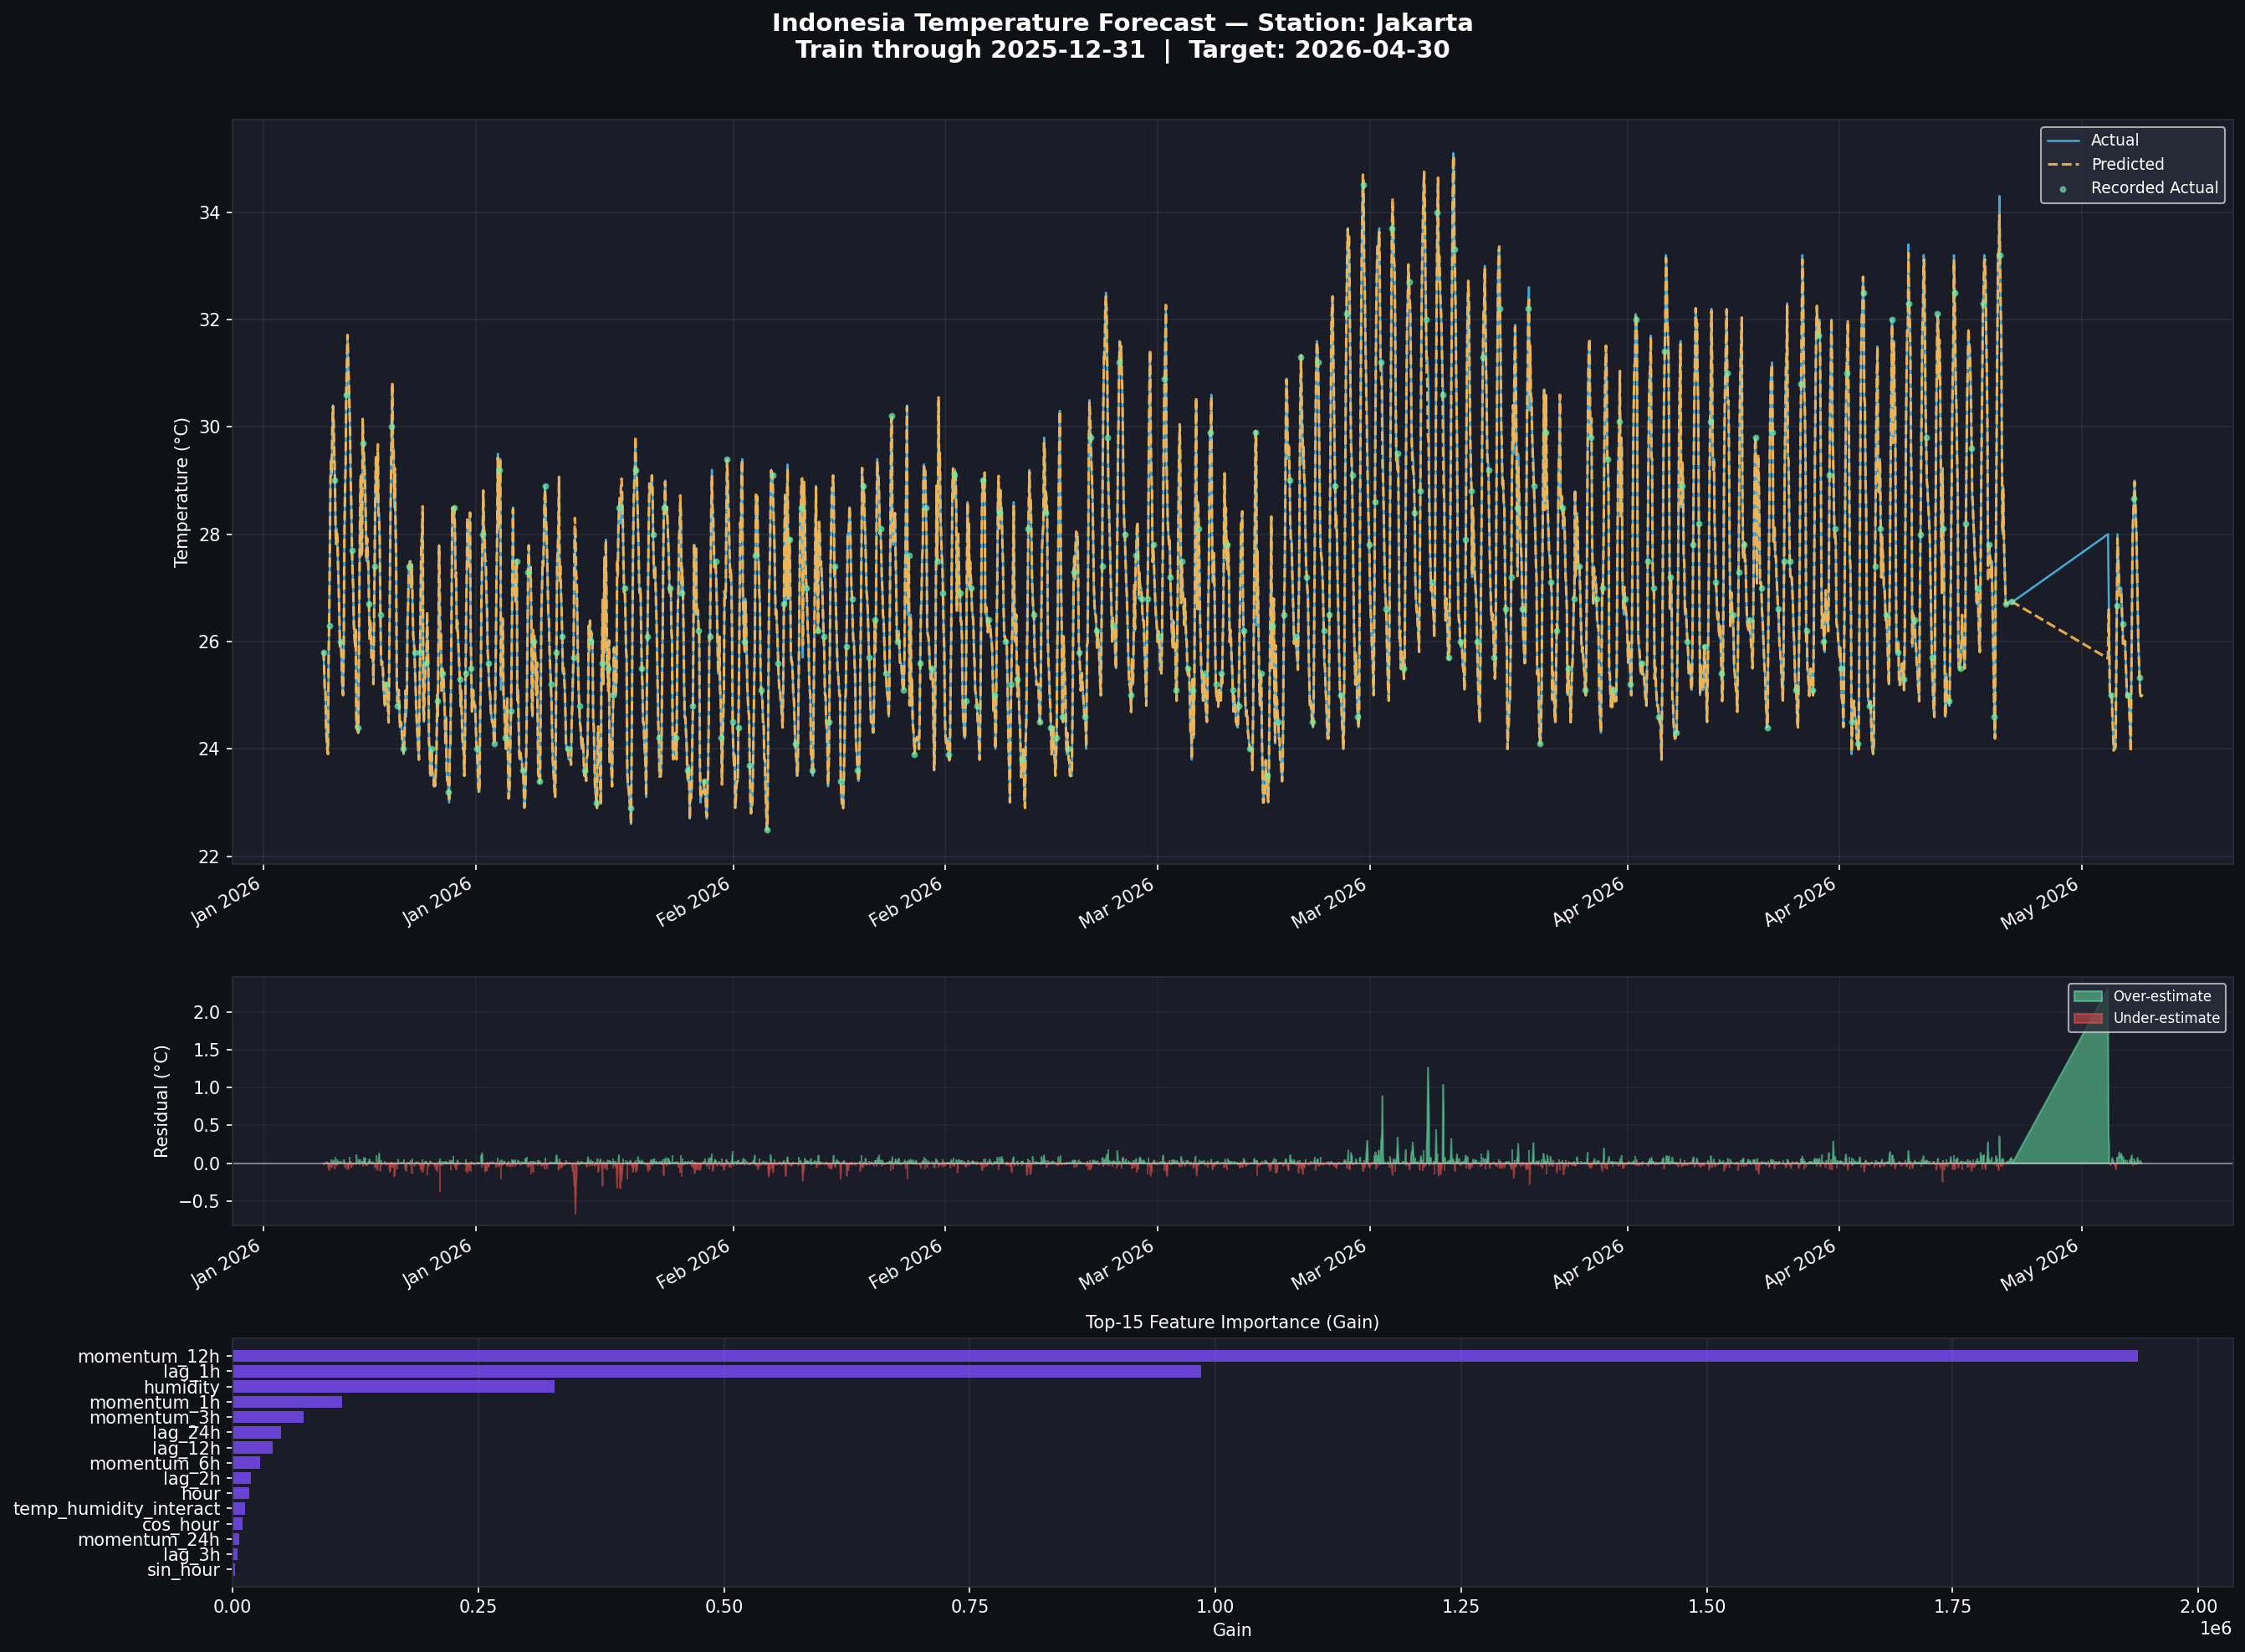

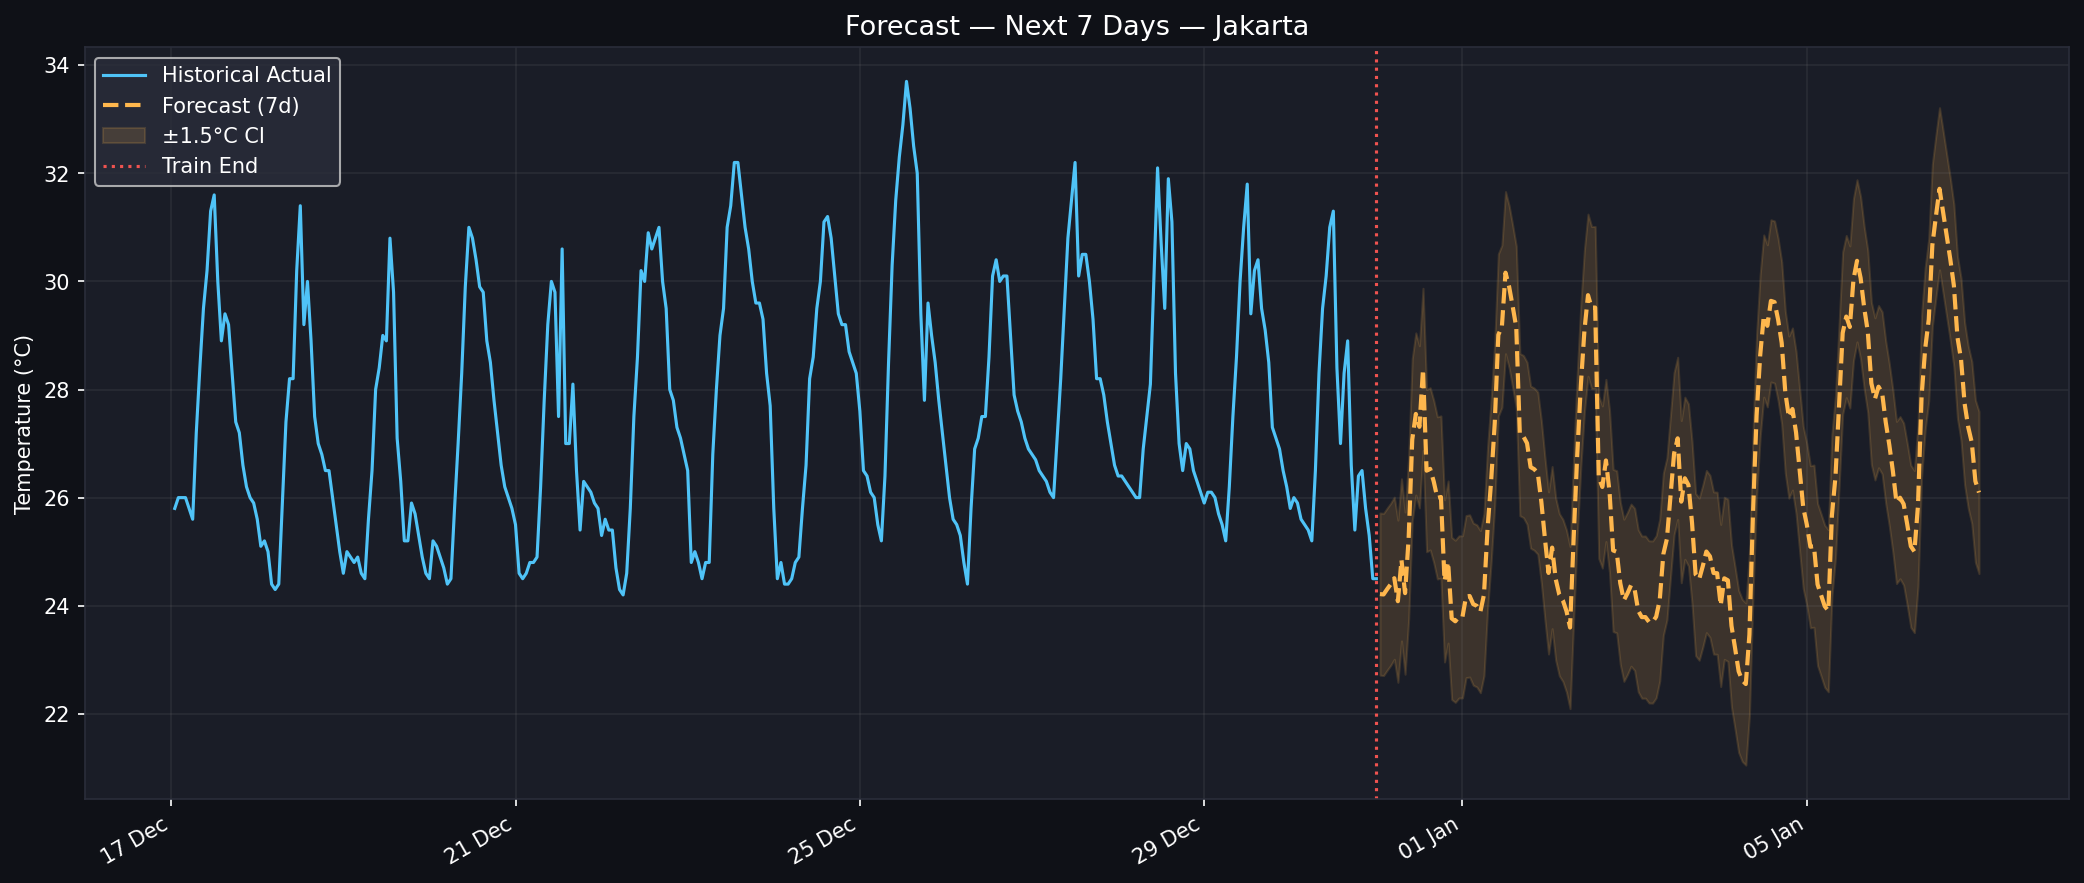

In [10]:
for name, res in results.items():
    mdl        = res["model"]
    df_full    = res["full_pred"]

    # Main plot (full period)
    img_path   = mdl.plot_results(df_full, last_n_days=120, save=True, show=CONFIG["SHOW_PLOTS"])
    # 7-day forecast horizon plot
    img_horizon= mdl.plot_forecast_horizon(df_full, horizon_days=7, save=True, show=CONFIG["SHOW_PLOTS"])

    print(f"\nPlot for {name}:")
    if os.path.exists(img_path):
        display(Image(img_path))
    if os.path.exists(img_horizon):
        display(Image(img_horizon))

## 📋 7. Summary Metrics — All Stations

In [11]:
rows = []
for name, res in results.items():
    m = res["metrics"]
    rows.append({
        "Station":   name,
        "MAE (°C)":  round(m.get("mae",  np.nan), 3),
        "RMSE (°C)": round(m.get("rmse", np.nan), 3),
        "MAPE (%)":  round(m.get("mape", np.nan), 2),
        "R²":        round(m.get("r2",   np.nan), 4),
    })

df_summary = pd.DataFrame(rows)
display(df_summary)

# Save summary
summary_path = os.path.join(CONFIG["OUTPUT_DIR"], "summary_metrics.csv")
df_summary.to_csv(summary_path, index=False)
print(f"\nSummary saved to: {summary_path}")

,Station,MAE (°C),RMSE (°C),MAPE (%),R²
0,Jakarta,0.035,0.07,0.13,0.9991



Summary saved to: output\summary_metrics.csv


## 🔍 8. Feature Importance Analysis

In [12]:
first_station = CONFIG["STATIONS"][0]
mdl = results[first_station]["model"]

imp_df = pd.DataFrame({
    "feature":    mdl.feature_cols,
    "importance": mdl.model.feature_importance(importance_type="gain"),
}).sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7), facecolor="#0f1117")
ax.set_facecolor("#1a1d27")
ax.barh(imp_df["feature"], imp_df["importance"], color="#7c4dff", alpha=0.85)
ax.set_title(f"Top-20 Feature Importance (Gain) — {first_station}", color="white", fontsize=13)
ax.set_xlabel("Gain", color="white")
ax.tick_params(colors="white")
ax.spines[:].set_color("#2a2d3a")
ax.invert_yaxis()
ax.grid(True, axis="x", alpha=0.15, color="gray")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["OUTPUT_DIR"], f"{first_station.lower()}_feature_importance.png"),
            dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


## 💾 9. Save Model

In [13]:
if CONFIG["SAVE_MODEL"]:
    for name, res in results.items():
        path = res["model"].save_model()
        print(f"  ok  {name} saved → {path}")
else:
    print("SAVE_MODEL=False, model not saved.")

2026-07-25 04:04:54,867 - INFO - [Model] Saved to: output\lgbm_jakarta.pkl


  ok  Jakarta saved → output\lgbm_jakarta.pkl


## 🚀 (Optional) Run via Full Orchestrator

Runs the entire pipeline at once through `main_bmkg_forecast.run_pipeline()` — useful for re-running with a different configuration without repeating each cell.

In [14]:
# ─── UNCOMMENT to run the full pipeline via the orchestrator ──────────────
# from main_bmkg_forecast import run_pipeline
#
# custom_config = {
#     "END_TRAIN":        "2024-06-30",
#     "TARGET_DATE":      "2024-12-31",
#     "STATIONS":         ["Bandung", "Surabaya"],
#     "HISTORICAL_START": "2020-01-01",
#     "FORCE_REFRESH":    False,
#     "SAVE_MODEL":       True,
#     "SHOW_PLOTS":       False,
# }
#
# results_alt = run_pipeline(custom_config)
print("Uncomment the code above to run the full pipeline.")

Uncomment the code above to run the full pipeline.
